# 🚀 Squad 2 - Real Time for Business

# Análise Exploratória de Dados - `ecommerce_pedidos`

Projeto desenvolvido durante o estágio de Engenharia de Dados, com objetivo de validar o fluxo de dados ponta a ponta, realizando ingestão, análise exploratória, validação da qualidade dos dados e disponibilização das informações para consumo analítico.

---

# 👥 Identificação da Equipe

**Squad:** 2 - Real Time for Business

**Dupla:** 3

**Integrantes:**

- Eduardo Geraldo de Souza
- Aliedson Soares Silva

---

# 🎯 Objetivo do Notebook

Este notebook tem como objetivo realizar a análise exploratória da tabela:

```
ecommerce_pedidos
```

A análise contempla duas fontes de dados:

---

# 📦 1. Histórico Completo (Batch)

## Fonte dos dados

```
Azure Data Lake Storage Gen2
```

Caminho:

```
batch-data/ecommerce_pedidos.csv
```

## Objetivo

Analisar o histórico completo dos pedidos, realizando:

- entendimento da estrutura dos dados;
- validação da qualidade das informações;
- análise do comportamento dos pedidos;
- geração de indicadores de negócio.

---

# ⚡ 2. Eventos em Tempo Real (Real Time)

## Fonte dos dados

```
Azure Data Lake Storage Gen2
```

Caminho:

```
real-time-data/*/ecommerce_pedidos.parquet
```

## Objetivo

Avaliar os novos eventos recebidos pela camada de tempo real, analisando:

- chegada de novos pedidos;
- estrutura dos arquivos Parquet;
- quantidade de registros recebidos;
- qualidade dos dados;
- disponibilidade para processamento analítico.

---

# 🏗️ Arquitetura do Fluxo de Dados

```
                 Azure Data Lake Storage Gen2

                          │

             ┌────────────┴────────────┐

             │                         │

       Batch Data              Real Time Data

             │                         │

 ecommerce_pedidos.csv     ecommerce_pedidos.parquet

             │                         │

             └────────────┬────────────┘

                          │

                    Databricks

                          │

              Análise Exploratória (EDA)

                          │

                    SQL Server Azure

                          │

              squad2.ecommerce_pedidos
```

---

# 🔎 Análises Realizadas

## Estrutura dos Dados

Serão avaliados:

- quantidade de registros;
- quantidade de colunas;
- tipos de dados;
- schema da tabela;
- amostragem dos registros.

---

## Qualidade dos Dados

Validações realizadas:

- valores nulos;
- registros duplicados;
- integridade da chave primária;
- consistência dos tipos de dados;
- validação de valores inválidos.

---

## Análise Histórica dos Pedidos

Serão analisados:

- evolução dos pedidos ao longo do tempo;
- volume mensal de pedidos;
- faturamento;
- ticket médio;
- distribuição dos status;
- métodos de pagamento;
- comportamento operacional.

---

## Análise dos Eventos Real Time

Serão avaliados:

- quantidade de pedidos recebidos na janela;
- horário da carga;
- novos pedidos processados;
- valor movimentado;
- status dos pedidos recebidos;
- comparação com o histórico.

---

# 📊 Comparação Batch x Real Time

A análise irá comparar:

| Característica | Batch | Real Time |
|---|---|---|
| Formato | CSV | Parquet |
| Objetivo | Histórico completo | Eventos recentes |
| Volume | Dados acumulados | Novas cargas |
| Frequência | Processamento em lote | Atualizações contínuas |
| Uso | Análise histórica | Monitoramento operacional |

---

# 🛠️ Tecnologias Utilizadas

- Python
- Pandas
- PySpark
- Databricks
- Azure Data Lake Storage Gen2
- SQL Server Azure
- DBeaver
- Git/GitHub

---

# 🗄️ Persistência dos Dados

Após a validação e análise exploratória, os dados serão disponibilizados no SQL Server utilizando o padrão:

```sql
squad2.ecommerce_pedidos
```

---

# 🔐 Segurança

As credenciais de acesso ao ambiente Azure são carregadas através de variáveis de ambiente utilizando arquivo `.env`.

Nenhuma informação sensível deve ser armazenada diretamente no código ou versionada no GitHub.

---

# ✅ Resultado Esperado

Ao final deste notebook será possível:

- validar a qualidade dos dados recebidos;
- compreender o comportamento histórico dos pedidos;
- analisar novos eventos em tempo real;
- gerar indicadores de negócio;
- disponibilizar a tabela para consumo analítico.

---

# 📌 Conclusão

Este notebook representa a etapa de análise exploratória da tabela `ecommerce_pedidos`, validando o fluxo de dados desde o Azure Data Lake Storage Gen2 até a camada analítica.

O objetivo principal é garantir que os dados recebidos estejam estruturados, confiáveis e preparados para utilização em análises de negócio.

In [0]:
# ==================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==================================================

# Biblioteca utilizada para manipulação e análise
# dos DataFrames durante a etapa exploratória.
import pandas as pd


# Biblioteca utilizada para criação dos gráficos
# e visualizações dos indicadores de negócio.
import matplotlib.pyplot as plt


# Permite trabalhar com arquivos carregados em memória,
# sendo utilizada principalmente para leitura de arquivos
# Parquet diretamente do Azure Data Lake.
from io import BytesIO


# Permite trabalhar com arquivos de texto em memória,
# utilizada para leitura dos arquivos CSV.
from io import StringIO


# Biblioteca responsável pela autenticação no Azure,
# utilizando Tenant ID, Client ID e Client Secret.
from azure.identity import ClientSecretCredential


# Cliente responsável pela comunicação com o
# Azure Data Lake Storage Gen2.
from azure.storage.filedatalake import DataLakeServiceClient


print(
    "Bibliotecas carregadas com sucesso!"
)

Bibliotecas carregadas com sucesso!


In [0]:
# ==================================================
# CARREGAMENTO DAS CONFIGURAÇÕES AZURE
# ==================================================

# Biblioteca responsável por carregar variáveis
# armazenadas no arquivo .env.
from dotenv import load_dotenv


# Biblioteca padrão do Python utilizada
# para acessar variáveis de ambiente.
import os



# --------------------------------------------------
# CARREGAR ARQUIVO .ENV
# --------------------------------------------------

# Realiza a leitura do arquivo .env,
# permitindo utilizar as credenciais sem
# expor informações sensíveis no código.
load_dotenv()



# --------------------------------------------------
# RECUPERAR CONFIGURAÇÕES DO AZURE
# --------------------------------------------------

# Recupera o identificador do aplicativo Azure
# utilizado para autenticação no Data Lake.
client_id = os.getenv(
    "ADLS_CLIENT_ID"
)


# Recupera o identificador do tenant Azure
# responsável pelo ambiente do estágio.
tenant_id = os.getenv(
    "ADLS_TENANT_ID"
)


# Recupera a chave secreta utilizada
# para autenticação da aplicação.
client_secret = os.getenv(
    "ADLS_CLIENT_SECRET"
)



# --------------------------------------------------
# CONFIGURAÇÕES DO DATA LAKE
# --------------------------------------------------

# Nome da conta de armazenamento Azure.
storage_account_name = os.getenv(
    "STORAGE_ACCOUNT_NAME"
)


# Container onde estão armazenados
# os arquivos utilizados pela Squad 2.
container_name = os.getenv(
    "CONTAINER_NAME"
)



# Arquivo histórico da tabela de pedidos.
arquivo_batch = (
    "batch-data/ecommerce_pedidos.csv"
)



print(
    "Configurações Azure carregadas com sucesso!"
)


print(
    "Storage Account:",
    storage_account_name
)


print(
    "Container:",
    container_name
)

Configurações Azure carregadas com sucesso!
Storage Account: internshipdatalake
Container: raw


In [0]:
# ==================================================
# AUTENTICAÇÃO AZURE DATA LAKE STORAGE GEN2
# ==================================================

# Classe responsável por criar a autenticação
# utilizando Tenant ID, Client ID e Client Secret.
from azure.identity import ClientSecretCredential



# --------------------------------------------------
# CRIAÇÃO DA CREDENCIAL AZURE
# --------------------------------------------------

# Cria a identidade da aplicação no Azure.
# Essa credencial será utilizada para acessar
# os arquivos armazenados no Data Lake.
credential = ClientSecretCredential(
    tenant_id=tenant_id,
    client_id=client_id,
    client_secret=client_secret
)



print(
    "Autenticação Azure criada com sucesso!"
)

Autenticação Azure criada com sucesso!


In [0]:
# ==================================================
# CONEXÃO COM AZURE DATA LAKE STORAGE GEN2
# ==================================================

# Biblioteca responsável pelo cliente
# de acesso ao Azure Data Lake Gen2.
from azure.storage.filedatalake import DataLakeServiceClient



# --------------------------------------------------
# CRIAÇÃO DO CLIENTE DO DATA LAKE
# --------------------------------------------------

# Monta a URL da conta de armazenamento Azure.
# O formato utilizado pelo ADLS Gen2 é:
# https://<storage-account>.dfs.core.windows.net

account_url = (
    f"https://{storage_account_name}.dfs.core.windows.net"
)



# Cria o cliente principal de comunicação
# com o Azure Data Lake Storage Gen2.
service_client = DataLakeServiceClient(
    account_url=account_url,
    credential=credential
)



# --------------------------------------------------
# ACESSO AO CONTAINER RAW
# --------------------------------------------------

# Seleciona o container onde estão
# armazenados os dados das squads.
file_system_client = (
    service_client
    .get_file_system_client(
        file_system=container_name
    )
)



print(
    "Conexão com Azure Data Lake criada com sucesso!"
)


print(
    "Container acessado:",
    container_name
)

Conexão com Azure Data Lake criada com sucesso!
Container acessado: raw


In [0]:
# ==================================================
# LISTAGEM DOS ARQUIVOS DISPONÍVEIS NO DATA LAKE
# ==================================================

# Percorre todos os caminhos existentes dentro
# do container raw para identificar os arquivos
# disponíveis para análise.

paths = (
    file_system_client
    .get_paths(
        recursive=True
    )
)


# Exibe os arquivos encontrados.
# Limitamos a quantidade exibida para facilitar
# a visualização no notebook.

contador = 0


for arquivo in paths:

    print(
        arquivo.name
    )

    contador += 1


    if contador >= 30:
        break


print(
    "\nListagem concluída!"
)

batch-data
batch-data/ecommerce_categorias.csv
batch-data/ecommerce_clientes.csv
batch-data/ecommerce_enderecos.csv
batch-data/ecommerce_itens_pedido.csv
batch-data/ecommerce_pedidos.csv
batch-data/ecommerce_produtos.csv
batch-data/ecommerce_rastreamento_entregas.csv
batch-data/food_avaliacoes_produto.csv
batch-data/food_estoque_lojas.csv
batch-data/food_fornecedores.csv
batch-data/food_lotes_producao.csv
batch-data/physical_itens_venda_caixa.csv
batch-data/physical_lojas.csv
batch-data/physical_produtos_pereciveis.csv
batch-data/physical_vendas_caixa.csv
real-time-data
real-time-data/2026
real-time-data/2026/09
real-time-data/2026/09/21
real-time-data/2026/09/21/112245
real-time-data/2026/09/21/112245/ecommerce_categorias.parquet
real-time-data/2026/09/21/112245/ecommerce_clientes.parquet
real-time-data/2026/09/21/112245/ecommerce_enderecos.parquet
real-time-data/2026/09/21/112245/ecommerce_itens_pedido.parquet
real-time-data/2026/09/21/112245/ecommerce_pedidos.parquet
real-time-data/

# 1. Carregamento do Histórico Completo (Batch)

Nesta etapa será realizada a leitura da tabela histórica
`ecommerce_pedidos`.

Fonte:

batch-data/ecommerce_pedidos.csv


O objetivo é carregar todos os pedidos históricos disponíveis
para realizar análises exploratórias, validação da qualidade dos dados
e geração de indicadores de negócio.

In [0]:
# ==================================================
# CARREGAMENTO HISTÓRICO COMPLETO - BATCH
# TABELA: ecommerce_pedidos
# ==================================================


# Importa biblioteca utilizada para leitura
# de arquivos CSV em memória.
from io import StringIO



# Define o caminho do arquivo histórico
# armazenado no Azure Data Lake.
arquivo_batch = (
    "batch-data/ecommerce_pedidos.csv"
)



# Cria o cliente para acessar o arquivo
# diretamente no Data Lake.
file_batch = (
    file_system_client
    .get_file_client(
        arquivo_batch
    )
)



# Realiza o download do arquivo CSV
# para memória temporária.
download_batch = (
    file_batch
    .download_file()
)



# Lê o conteúdo do arquivo.
# O decode transforma os bytes recebidos
# em texto para leitura pelo Pandas.
conteudo_batch = (
    download_batch
    .readall()
    .decode("utf-8")
)



# Cria o DataFrame Pandas contendo
# o histórico completo dos pedidos.
df_historico = pd.read_csv(
    StringIO(conteudo_batch)
)



# ==================================================
# VALIDAÇÃO INICIAL
# ==================================================

print(
    "Histórico Batch carregado com sucesso!"
)


print(
    "Quantidade de registros e colunas:"
)


print(
    df_historico.shape
)

Histórico Batch carregado com sucesso!
Quantidade de registros e colunas:
(90335, 10)


# 2. Visualização Inicial dos Dados

Nesta etapa será realizada uma inspeção inicial da tabela
`ecommerce_pedidos`, permitindo visualizar exemplos dos registros
carregados e compreender a estrutura das informações disponíveis.

In [0]:
# ==================================================
# ESTRUTURA DOS DADOS
# ==================================================


# Apresenta informações gerais da tabela:
# - nomes das colunas;
# - tipos dos dados;
# - quantidade de valores preenchidos.
df_historico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90335 entries, 0 to 90334
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_pedido                     90335 non-null  int64  
 1   id_cliente                    90335 non-null  int64  
 2   id_endereco_entrega           90335 non-null  int64  
 3   dt_pedido                     90335 non-null  object 
 4   status_pedido                 90335 non-null  object 
 5   valor_total                   90335 non-null  float64
 6   valor_frete                   90335 non-null  float64
 7   metodo_pagamento              90335 non-null  object 
 8   dt_previsao_entrega           90335 non-null  object 
 9   dt_ultima_atualizacao_status  90335 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 6.9+ MB


In [0]:
# ==================================================
# ESTATÍSTICAS DESCRITIVAS
# ==================================================


# Calcula estatísticas das colunas numéricas:
# - quantidade;
# - média;
# - mínimo;
# - máximo;
# - quartis.
df_historico.describe()

,id_pedido,id_cliente,id_endereco_entrega,valor_total,valor_frete
count,90335.000000,90335.000000,90335.000000,90335.000000,90335.000000
mean,45168.000000,4999.874146,5224.251032,842.060074,0.854751
std,26077.612621,2885.859475,3010.353486,454.496226,3.412614
min,1.000000,1.000000,1.000000,23.530000,0.000000
25%,22584.500000,2500.000000,2616.000000,478.595000,0.000000
50%,45168.000000,5006.000000,5234.000000,786.440000,0.000000
75%,67751.500000,7497.000000,7832.000000,1148.130000,0.000000
max,90335.000000,10000.000000,10428.000000,3627.960000,34.990000


In [0]:
# ==================================================
# ESTATÍSTICAS DESCRITIVAS
# ==================================================


# Calcula estatísticas das colunas numéricas:
# - quantidade;
# - média;
# - mínimo;
# - máximo;
# - quartis.
df_historico.describe()

,id_pedido,id_cliente,id_endereco_entrega,valor_total,valor_frete
count,90335.000000,90335.000000,90335.000000,90335.000000,90335.000000
mean,45168.000000,4999.874146,5224.251032,842.060074,0.854751
std,26077.612621,2885.859475,3010.353486,454.496226,3.412614
min,1.000000,1.000000,1.000000,23.530000,0.000000
25%,22584.500000,2500.000000,2616.000000,478.595000,0.000000
50%,45168.000000,5006.000000,5234.000000,786.440000,0.000000
75%,67751.500000,7497.000000,7832.000000,1148.130000,0.000000
max,90335.000000,10000.000000,10428.000000,3627.960000,34.990000


# Tratamento das Datas

As colunas de data foram convertidas para o formato datetime,
permitindo análises temporais e criação de indicadores históricos.

In [0]:
# ==================================================
# CONVERSÃO DAS COLUNAS DE DATA
# ==================================================

# Lista das colunas que representam datas
# dentro da tabela ecommerce_pedidos.

colunas_data = [
    "dt_pedido",
    "dt_previsao_entrega",
    "dt_ultima_atualizacao_status"
]


# Converte as colunas para o formato datetime.
# Isso permite realizar operações como:
# - agrupamento por mês;
# - cálculo de períodos;
# - análise de atrasos.

for coluna in colunas_data:
    
    df_historico[coluna] = pd.to_datetime(
        df_historico[coluna]
    )


print(
    "Conversão das datas realizada com sucesso!"
)

Conversão das datas realizada com sucesso!


# Análise de Qualidade dos Dados

## Valores Nulos

Nesta etapa será realizada a validação de valores ausentes
nas colunas da tabela `ecommerce_pedidos`.

O objetivo é identificar possíveis falhas de preenchimento
que possam impactar as análises e indicadores de negócio.

In [0]:
# ==================================================
# ANÁLISE DE VALORES NULOS
# ==================================================


# Calcula a quantidade de valores ausentes
# em cada coluna da tabela.

nulos = (
    df_historico
    .isnull()
    .sum()
)


# Exibe somente as colunas
# que possuem valores nulos.

nulos[
    nulos > 0
]

Series([], dtype: int64)

## Valores Nulos

Foi realizada a análise de valores ausentes na tabela
`ecommerce_pedidos`.

Resultado:

- Nenhum valor nulo foi identificado nas colunas analisadas.

Conclusão:

A tabela apresenta consistência quanto ao preenchimento
dos dados.

In [0]:
# ==================================================
# ANÁLISE DE REGISTROS DUPLICADOS
# ==================================================

# Verifica se existem linhas totalmente duplicadas
# dentro da tabela de pedidos.

duplicados = (
    df_historico
    .duplicated()
    .sum()
)


print(
    "Quantidade de registros duplicados:",
    duplicados
)

Quantidade de registros duplicados: 0


In [0]:
# ==================================================
# VALIDAÇÃO DA CHAVE PRIMÁRIA
# COLUNA: id_pedido
# ==================================================


# Conta o total de registros existentes
# na tabela histórica.

total_registros = len(
    df_historico
)


# Conta quantos pedidos diferentes existem.
# O ideal é que esse número seja igual
# ao total de registros.

pedidos_unicos = (
    df_historico["id_pedido"]
    .nunique()
)


print(
    "Total de registros:",
    total_registros
)


print(
    "Pedidos únicos:",
    pedidos_unicos
)


# Calcula possíveis duplicidades
# somente considerando a chave do pedido.

duplicidade_chave = (
    total_registros - pedidos_unicos
)


print(
    "Duplicidades na chave id_pedido:",
    duplicidade_chave
)

Total de registros: 90335
Pedidos únicos: 90335
Duplicidades na chave id_pedido: 0


# Validação da Qualidade dos Dados

Foram realizadas validações na tabela
`ecommerce_pedidos`:

## Valores Nulos

Resultado:

- Nenhum valor nulo encontrado.


## Registros Duplicados

Resultado:

- Nenhum registro duplicado identificado.


## Integridade da Chave Primária

Campo analisado:

id_pedido


Resultado:

- 90.335 registros analisados;
- 90.335 pedidos únicos;
- nenhuma duplicidade encontrada.

Conclusão:

A tabela apresenta consistência estrutural e integridade
na identificação dos pedidos.


# Análise Temporal dos Pedidos

Nesta etapa será analisada a evolução histórica dos pedidos ao longo do tempo.

A partir da coluna `dt_pedido`, será criada uma variável mensal para permitir a análise de volume de pedidos por período.

In [0]:
# ==================================================
# CRIAÇÃO DA COLUNA MÊS DO PEDIDO
# ==================================================

# Cria uma cópia do DataFrame histórico
# para preservar os dados originais.

df_analise = df_historico.copy()



# Cria uma nova coluna contendo
# o ano e mês do pedido.
#
# Essa coluna será utilizada para
# agrupamentos e criação dos gráficos.

df_analise["mes_pedido"] = (
    df_analise["dt_pedido"]
    .dt.to_period("M")
    .astype(str)
)



print(
    "Coluna mes_pedido criada com sucesso!"
)


# Exibe uma amostra para validação.

df_analise[
    [
        "dt_pedido",
        "mes_pedido"
    ]
].head()

Coluna mes_pedido criada com sucesso!


,dt_pedido,mes_pedido
0,2025-12-04 08:00:59,2025-12
1,2025-02-08 21:55:31,2025-02
2,2024-06-02 12:33:15,2024-06
3,2025-11-08 23:23:06,2025-11
4,2024-11-06 01:21:51,2024-11


# Evolução Mensal dos Pedidos

Nesta análise será avaliada a quantidade de pedidos realizados ao longo do período histórico.

O objetivo é identificar tendências de crescimento, redução ou sazonalidade no volume de pedidos.

In [0]:
# ==================================================
# QUANTIDADE DE PEDIDOS POR MÊS
# ==================================================


# Agrupa os pedidos pelo mês de realização
# e conta a quantidade de pedidos em cada período.

pedidos_por_mes = (
    df_analise
    .groupby("mes_pedido")
    .size()
    .reset_index(
        name="quantidade_pedidos"
    )
)



# Ordena os meses cronologicamente.

pedidos_por_mes = (
    pedidos_por_mes
    .sort_values(
        "mes_pedido"
    )
)



# Visualiza o resultado.

pedidos_por_mes.head()

,mes_pedido,quantidade_pedidos
0,2024-01,2470
1,2024-02,1910
2,2024-03,2862
3,2024-04,2537
4,2024-05,3225


# Gráfico - Evolução Mensal dos Pedidos

Este gráfico apresenta a quantidade de pedidos realizados ao longo do período histórico.

O objetivo é identificar tendências de crescimento, redução ou comportamento sazonal do volume de pedidos.

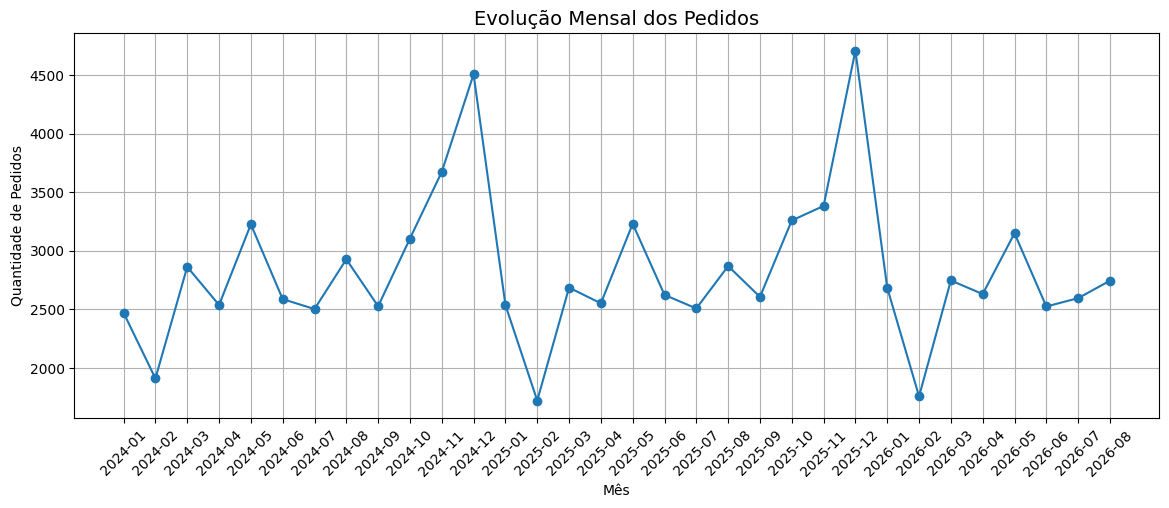

In [0]:
# ==================================================
# GRÁFICO - EVOLUÇÃO MENSAL DOS PEDIDOS
# ==================================================


# Define o tamanho da área do gráfico.
plt.figure(
    figsize=(14, 5)
)


# Cria o gráfico de linha.
# Eixo X: meses
# Eixo Y: quantidade de pedidos

plt.plot(
    pedidos_por_mes["mes_pedido"],
    pedidos_por_mes["quantidade_pedidos"],
    marker="o"
)



# Define o título do gráfico.

plt.title(
    "Evolução Mensal dos Pedidos",
    fontsize=14
)



# Nome dos eixos.

plt.xlabel(
    "Mês"
)

plt.ylabel(
    "Quantidade de Pedidos"
)



# Rotaciona os meses para facilitar a leitura.

plt.xticks(
    rotation=45
)



# Adiciona uma grade para facilitar comparação visual.

plt.grid(
    True
)



# Exibe o gráfico.

plt.show()

# Faturamento Mensal

Nesta análise será avaliado o comportamento financeiro dos pedidos ao longo do período histórico.

O objetivo é identificar os meses com maior geração de receita e comparar o comportamento financeiro com o volume de pedidos.

In [0]:
# ==================================================
# FATURAMENTO MENSAL
# ==================================================


# Agrupa os pedidos por mês e soma
# o valor total das vendas realizadas.

faturamento_por_mes = (
    df_analise
    .groupby("mes_pedido")
    ["valor_total"]
    .sum()
    .reset_index()
)



# Renomeia a coluna para deixar
# o significado mais claro.

faturamento_por_mes = (
    faturamento_por_mes
    .rename(
        columns={
            "valor_total": "faturamento"
        }
    )
)



# Ordena cronologicamente.

faturamento_por_mes = (
    faturamento_por_mes
    .sort_values(
        "mes_pedido"
    )
)



# Visualização inicial.

faturamento_por_mes.head()

,mes_pedido,faturamento
0,2024-01,2106983.27
1,2024-02,1590523.28
2,2024-03,2386503.91
3,2024-04,2178618.08
4,2024-05,2685740.70


# Gráfico - Faturamento Mensal

Este gráfico apresenta a evolução da receita gerada pelos pedidos ao longo do período histórico.

O objetivo é identificar períodos de maior faturamento e avaliar o comportamento financeiro do e-commerce.

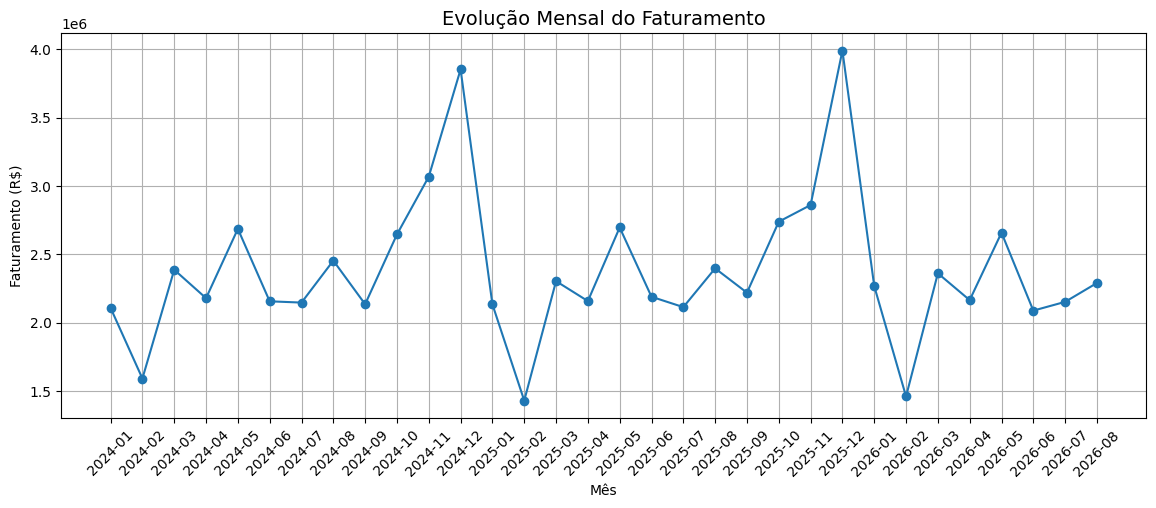

In [0]:
# ==================================================
# GRÁFICO - FATURAMENTO MENSAL
# ==================================================


# Define o tamanho do gráfico.

plt.figure(
    figsize=(14,5)
)



# Cria gráfico de linha mostrando
# a evolução do faturamento.

plt.plot(
    faturamento_por_mes["mes_pedido"],
    faturamento_por_mes["faturamento"],
    marker="o"
)



# Define título.

plt.title(
    "Evolução Mensal do Faturamento",
    fontsize=14
)



# Define nomes dos eixos.

plt.xlabel(
    "Mês"
)


plt.ylabel(
    "Faturamento (R$)"
)



# Ajusta os rótulos dos meses.

plt.xticks(
    rotation=45
)



# Exibe uma grade para facilitar leitura.

plt.grid(
    True
)



# Exibe o gráfico.

plt.show()

# Ticket Médio Mensal

O ticket médio representa o valor médio gerado por pedido.

Esse indicador permite avaliar se os clientes estão realizando compras de maior ou menor valor ao longo do tempo.

In [0]:
# ==================================================
# CÁLCULO DO TICKET MÉDIO MENSAL
# ==================================================


# Junta as informações de quantidade de pedidos
# com o faturamento mensal.

ticket_medio_mes = (
    pedidos_por_mes
    .merge(
        faturamento_por_mes,
        on="mes_pedido"
    )
)



# Calcula o ticket médio:
#
# faturamento / quantidade de pedidos

ticket_medio_mes["ticket_medio"] = (
    ticket_medio_mes["faturamento"]
    /
    ticket_medio_mes["quantidade_pedidos"]
)



# Visualiza o resultado.

ticket_medio_mes.head()

,mes_pedido,quantidade_pedidos,faturamento,ticket_medio
0,2024-01,2470,2106983.27,853.029664
1,2024-02,1910,1590523.28,832.734702
2,2024-03,2862,2386503.91,833.858809
3,2024-04,2537,2178618.08,858.737911
4,2024-05,3225,2685740.70,832.787814


# Gráfico - Ticket Médio Mensal

Este gráfico apresenta a evolução do valor médio gerado por pedido ao longo do período histórico.

O objetivo é identificar alterações no comportamento de compra dos clientes.

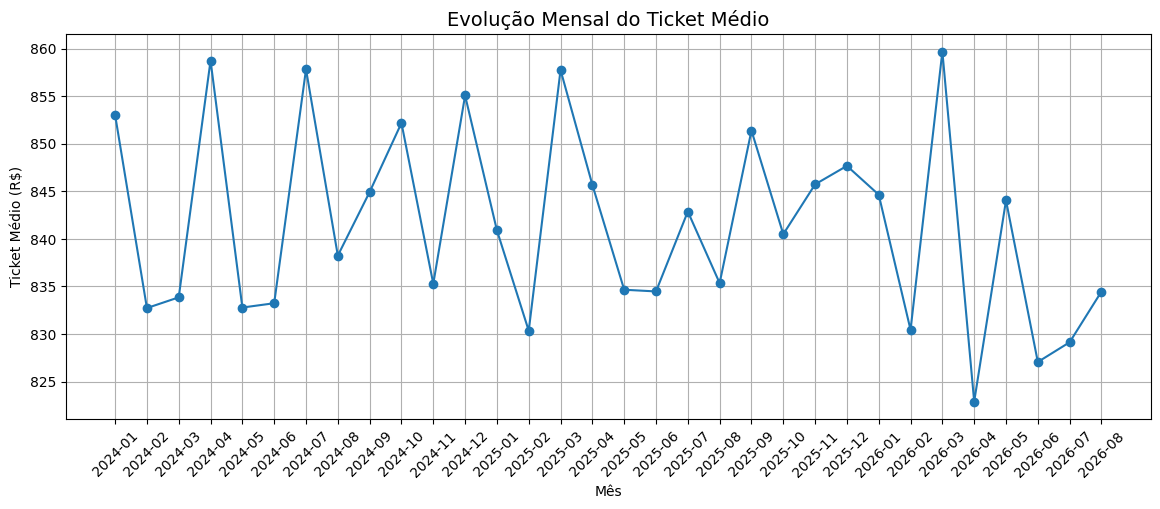

In [0]:
# ==================================================
# GRÁFICO - TICKET MÉDIO MENSAL
# ==================================================


plt.figure(
    figsize=(14,5)
)


plt.plot(
    ticket_medio_mes["mes_pedido"],
    ticket_medio_mes["ticket_medio"],
    marker="o"
)


plt.title(
    "Evolução Mensal do Ticket Médio",
    fontsize=14
)


plt.xlabel(
    "Mês"
)


plt.ylabel(
    "Ticket Médio (R$)"
)


plt.xticks(
    rotation=45
)


plt.grid(
    True
)


plt.show()

## Análise do Ticket Médio

O ticket médio apresentou comportamento estável durante o período analisado, permanecendo aproximadamente entre R$ 825 e R$ 860.

A estabilidade desse indicador indica que as principais variações de faturamento observadas anteriormente estão relacionadas principalmente ao volume de pedidos realizados, e não a grandes alterações no valor médio das compras.

Esse indicador permite acompanhar mudanças no comportamento de consumo dos clientes e auxilia na avaliação da performance comercial.

# Distribuição dos Status dos Pedidos

Nesta análise será avaliada a distribuição dos pedidos conforme seu status operacional.

O objetivo é compreender o comportamento da operação logística e identificar a proporção de pedidos concluídos, em processamento ou cancelados.

In [0]:
# ==================================================
# DISTRIBUIÇÃO DOS STATUS DOS PEDIDOS
# ==================================================


# Conta a quantidade de pedidos
# para cada status existente.

status_pedidos = (
    df_historico
    ["status_pedido"]
    .value_counts()
    .reset_index()
)


# Renomeia as colunas para facilitar leitura.

status_pedidos.columns = [
    "status_pedido",
    "quantidade"
]


status_pedidos

,status_pedido,quantidade
0,Entregue,54175
1,Enviado,13608
2,Em Separação,9007
3,Cancelado,4554
4,Pagamento Aprovado,4549
5,Processando,4442


In [0]:
# ==================================================
# TAXA DE CANCELAMENTO DOS PEDIDOS
# ==================================================


# Quantidade total de pedidos.

total_pedidos = (
    df_historico
    .shape[0]
)



# Quantidade de pedidos cancelados.

pedidos_cancelados = (
    df_historico
    [
        df_historico["status_pedido"] == "Cancelado"
    ]
    .shape[0]
)



# Calcula o percentual de cancelamentos.

taxa_cancelamento = (
    pedidos_cancelados
    /
    total_pedidos
) * 100



print(
    "Total de pedidos:",
    total_pedidos
)


print(
    "Pedidos cancelados:",
    pedidos_cancelados
)


print(
    f"Taxa de cancelamento: {taxa_cancelamento:.2f}%"
)

Total de pedidos: 90335
Pedidos cancelados: 4554
Taxa de cancelamento: 5.04%


## Taxa de Cancelamento

Foi realizada a análise da proporção de pedidos cancelados em relação ao total de pedidos históricos.

Resultados encontrados:

- Total de pedidos analisados: 90.335
- Pedidos cancelados: 4.554
- Taxa de cancelamento: 5,04%

A análise permite acompanhar a eficiência operacional e identificar possíveis oportunidades de melhoria no processo de venda e entrega.

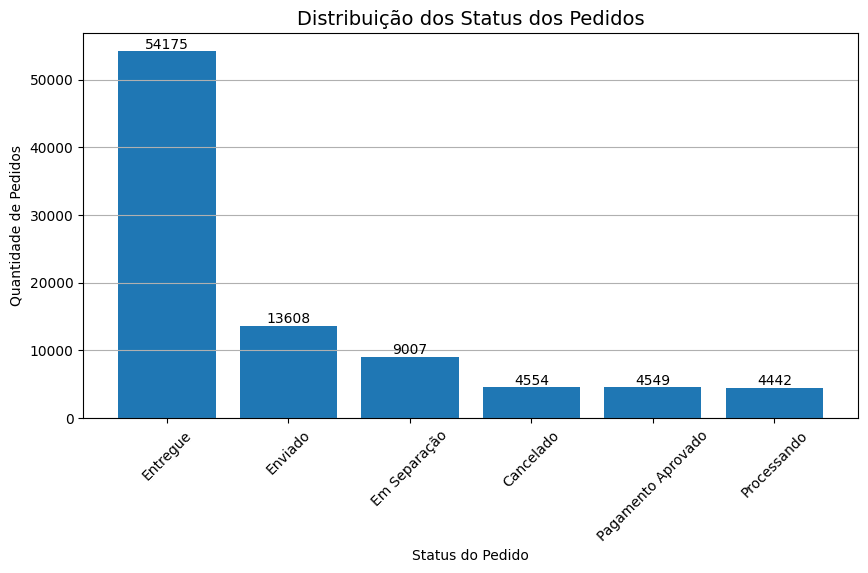

In [0]:
# ==================================================
# GRÁFICO - STATUS DOS PEDIDOS
# ==================================================


# Define tamanho do gráfico.

plt.figure(
    figsize=(10,5)
)


# Cria gráfico de barras.

plt.bar(
    status_pedidos["status_pedido"],
    status_pedidos["quantidade"]
)


# Título.

plt.title(
    "Distribuição dos Status dos Pedidos",
    fontsize=14
)


# Nome dos eixos.

plt.xlabel(
    "Status do Pedido"
)


plt.ylabel(
    "Quantidade de Pedidos"
)


# Rotaciona os nomes dos status.

plt.xticks(
    rotation=45
)


# Exibe valores.

for i, valor in enumerate(
    status_pedidos["quantidade"]
):
    
    plt.text(
        i,
        valor,
        str(valor),
        ha="center",
        va="bottom"
    )


plt.grid(
    axis="y"
)


plt.show()

## Análise dos Status dos Pedidos

A análise da distribuição dos status permitiu compreender o estágio operacional dos pedidos.

Principais resultados:

- 54.175 pedidos encontram-se como entregues;
- 13.608 pedidos estão enviados;
- 9.007 pedidos estão em separação;
- 4.554 pedidos foram cancelados;
- 4.549 pedidos possuem pagamento aprovado;
- 4.442 pedidos estão em processamento.

A maior concentração está no status "Entregue", indicando que a maior parte dos pedidos percorreu todo o fluxo operacional.

# Análise dos Métodos de Pagamento

Nesta etapa será analisada a distribuição dos pedidos conforme o método de pagamento utilizado pelos clientes.

O objetivo é identificar quais formas de pagamento possuem maior participação no volume de pedidos.

In [0]:
# ==================================================
# QUANTIDADE DE PEDIDOS POR MÉTODO DE PAGAMENTO
# ==================================================


# Agrupa os pedidos pelo método de pagamento
# e contabiliza a quantidade de pedidos
# realizados em cada categoria.

pagamentos_quantidade = (
    df_historico
    ["metodo_pagamento"]
    .value_counts()
    .reset_index()
)



# Renomeia as colunas para facilitar
# interpretação e utilização nos gráficos.

pagamentos_quantidade.columns = [
    "metodo_pagamento",
    "quantidade_pedidos"
]



# Exibe o resultado.

pagamentos_quantidade

,metodo_pagamento,quantidade_pedidos
0,Cartão de Crédito,58662
1,Pix,27177
2,Boleto,4496


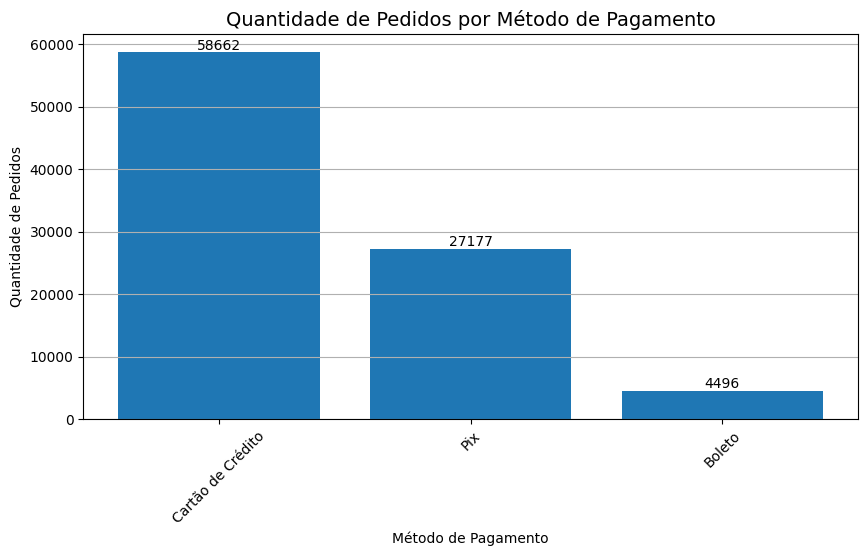

In [0]:
# ==================================================
# GRÁFICO - MÉTODOS DE PAGAMENTO
# ==================================================


plt.figure(
    figsize=(10,5)
)


plt.bar(
    pagamentos_quantidade["metodo_pagamento"],
    pagamentos_quantidade["quantidade_pedidos"]
)



plt.title(
    "Quantidade de Pedidos por Método de Pagamento",
    fontsize=14
)



plt.xlabel(
    "Método de Pagamento"
)


plt.ylabel(
    "Quantidade de Pedidos"
)



plt.xticks(
    rotation=45
)



# Adiciona os valores acima das barras.

for i, valor in enumerate(
    pagamentos_quantidade["quantidade_pedidos"]
):
    
    plt.text(
        i,
        valor,
        str(valor),
        ha="center",
        va="bottom"
    )



plt.grid(
    axis="y"
)


plt.show()

## Análise dos Métodos de Pagamento

A análise dos métodos de pagamento demonstrou a preferência dos clientes pelas diferentes formas de pagamento disponíveis.

Resultados:

- Cartão de Crédito: 58.662 pedidos;
- Pix: 27.177 pedidos;
- Boleto: 4.496 pedidos.

O cartão de crédito apresentou a maior participação entre os pedidos analisados, seguido pelo Pix. O boleto apresentou menor utilização no período avaliado.

Essa análise permite compreender o comportamento de pagamento dos clientes e apoiar decisões relacionadas à experiência de compra.

# Faturamento por Método de Pagamento

Nesta análise será avaliado o valor financeiro gerado por cada método de pagamento.

O objetivo é identificar quais formas de pagamento possuem maior participação no faturamento total.

In [0]:
# ==================================================
# FATURAMENTO POR MÉTODO DE PAGAMENTO
# ==================================================


# Agrupa os pedidos pelo método de pagamento
# e soma o valor total das compras realizadas.

pagamentos_faturamento = (
    df_historico
    .groupby(
        "metodo_pagamento"
    )
    ["valor_total"]
    .sum()
    .reset_index()
)



# Renomeia a coluna para facilitar leitura.

pagamentos_faturamento = (
    pagamentos_faturamento
    .rename(
        columns={
            "valor_total": "faturamento"
        }
    )
)



# Ordena do maior para o menor faturamento.

pagamentos_faturamento = (
    pagamentos_faturamento
    .sort_values(
        "faturamento",
        ascending=False
    )
)



pagamentos_faturamento

,metodo_pagamento,faturamento
1,Cartão de Crédito,49410613.01
2,Pix,22923538.34
0,Boleto,3733345.47


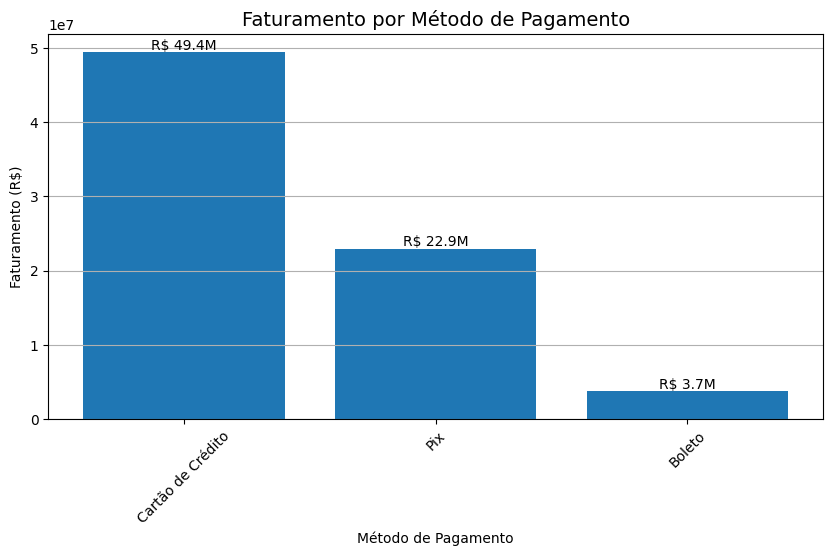

In [0]:
# ==================================================
# GRÁFICO - FATURAMENTO POR MÉTODO DE PAGAMENTO
# ==================================================


plt.figure(
    figsize=(10,5)
)


plt.bar(
    pagamentos_faturamento["metodo_pagamento"],
    pagamentos_faturamento["faturamento"]
)


plt.title(
    "Faturamento por Método de Pagamento",
    fontsize=14
)


plt.xlabel(
    "Método de Pagamento"
)


plt.ylabel(
    "Faturamento (R$)"
)


plt.xticks(
    rotation=45
)


# Exibe os valores acima das barras.

for i, valor in enumerate(
    pagamentos_faturamento["faturamento"]
):

    plt.text(
        i,
        valor,
        f"R$ {valor/1000000:.1f}M",
        ha="center",
        va="bottom"
    )


plt.grid(
    axis="y"
)


plt.show()

# ⚡ Eventos em Tempo Real (Real Time)

Nesta etapa será realizada a análise dos novos eventos recebidos pela camada de dados em tempo real.

Fonte:

real-time-data/2026/09/21/112245/ecommerce_pedidos.parquet


Objetivos:

- validar a chegada dos novos pedidos;
- analisar a estrutura dos eventos recebidos;
- verificar a qualidade dos dados;
- comparar os eventos recentes com o histórico completo.

In [0]:
# ==================================================
# CARREGAMENTO DOS EVENTOS REAL TIME
# TABELA: ecommerce_pedidos
# ==================================================


# Importa biblioteca necessária para trabalhar
# com arquivos Parquet carregados em memória.

from io import BytesIO



# --------------------------------------------------
# DEFINIÇÃO DO ARQUIVO REAL TIME
# --------------------------------------------------

# Caminho da janela de dados recebida.
# Cada pasta representa uma nova carga/evento.

arquivo_realtime = (
    "real-time-data/2026/09/21/112245/ecommerce_pedidos.parquet"
)



# --------------------------------------------------
# ACESSO AO ARQUIVO NO DATA LAKE
# --------------------------------------------------

# Cria o cliente para acessar o arquivo Parquet.

file_realtime = (
    file_system_client
    .get_file_client(
        arquivo_realtime
    )
)



# Realiza o download do arquivo.

download_realtime = (
    file_realtime
    .download_file()
)



# Lê o conteúdo do arquivo em memória.

conteudo_realtime = (
    download_realtime
    .readall()
)



# --------------------------------------------------
# CONVERSÃO PARA DATAFRAME
# --------------------------------------------------

# Converte o arquivo Parquet para um DataFrame Pandas.

df_realtime = pd.read_parquet(
    BytesIO(conteudo_realtime)
)



print(
    "Eventos Real Time carregados com sucesso!"
)


print(
    "Quantidade de registros e colunas:"
)


print(
    df_realtime.shape
)

Eventos Real Time carregados com sucesso!
Quantidade de registros e colunas:
(6, 10)


# Visualização dos Eventos Real Time

Nesta etapa serão apresentados os pedidos recebidos na última janela de processamento.

O objetivo é validar quais eventos chegaram e suas principais informações.

In [0]:
# ==================================================
# VISUALIZAÇÃO DOS EVENTOS REAL TIME
# ==================================================


# Exibe os primeiros registros
# recebidos na janela de processamento.

df_realtime.head()

,id_pedido,id_cliente,id_endereco_entrega,dt_pedido,status_pedido,valor_total,valor_frete,metodo_pagamento,dt_previsao_entrega,dt_ultima_atualizacao_status
0,1790000559,1790000561,1790000562,2026-09-21 11:22:04.299943,Aguardando,65.00,13.35,boleto,2026-09-29 11:22:04.299943,2026-09-21 11:22:04.299943
1,1790000560,1790000561,1790000562,2026-09-21 11:22:36.300030,Processando,128.12,19.51,boleto,2026-09-28 11:22:36.300030,2026-09-21 11:22:36.300030
2,1790000561,1790000559,1790000559,2026-09-21 11:21:51.300169,Pagamento Aprovado,271.93,24.31,cartão débito,2026-09-26 11:21:51.300169,2026-09-21 11:21:51.300169
3,1790000562,1790000560,1790000561,2026-09-21 11:21:48.300288,Pagamento Aprovado,18.66,19.29,boleto,2026-09-28 11:21:48.300288,2026-09-21 11:21:48.300288
4,1790000563,1790000561,1790000562,2026-09-21 11:22:07.300310,Processando,221.31,23.30,pix,2026-09-27 11:22:07.300310,2026-09-21 11:22:07.300310


# Comparação de Estrutura - Batch x Real Time

Nesta etapa será realizada a comparação entre a estrutura do histórico completo e os eventos recebidos em tempo real.

O objetivo é garantir que os novos eventos possuem compatibilidade com o modelo histórico da tabela `ecommerce_pedidos`.

In [0]:
# ==================================================
# COMPARAÇÃO DAS COLUNAS
# HISTÓRICO X REAL TIME
# ==================================================


# Obtém as colunas existentes
# no histórico completo.

colunas_historico = (
    set(df_historico.columns)
)



# Obtém as colunas existentes
# nos eventos real time.

colunas_realtime = (
    set(df_realtime.columns)
)



# Verifica diferenças entre as estruturas.

diferencas = (
    colunas_historico
    .symmetric_difference(
        colunas_realtime
    )
)



print(
    "Colunas do Histórico:"
)

print(
    len(colunas_historico)
)


print(
    "\nColunas Real Time:"
)

print(
    len(colunas_realtime)
)


print(
    "\nDiferenças encontradas:"
)

print(
    diferencas
)

Colunas do Histórico:
10

Colunas Real Time:
10

Diferenças encontradas:
set()


# Análise da Janela Real Time

Nesta etapa serão analisados os eventos recebidos na última janela de processamento.

O objetivo é identificar o volume de pedidos recebidos e seus principais indicadores de negócio.

In [0]:
# ==================================================
# VOLUME DE PEDIDOS RECEBIDOS - REAL TIME
# ==================================================


# Conta a quantidade de pedidos
# recebidos na janela atual.

quantidade_eventos = (
    len(df_realtime)
)


print(
    "Quantidade de pedidos recebidos na janela:",
    quantidade_eventos
)

Quantidade de pedidos recebidos na janela: 6


In [0]:
# ==================================================
# VALOR MOVIMENTADO - REAL TIME
# ==================================================


# Soma o valor total dos pedidos
# recebidos na janela atual.

valor_real_time = (
    df_realtime["valor_total"]
    .sum()
)


print(
    f"Valor movimentado na janela: R$ {valor_real_time:,.2f}"
)

Valor movimentado na janela: R$ 754.66


# Status dos Eventos Real Time

Nesta etapa será analisada a distribuição dos status dos pedidos recebidos na última janela de processamento.

O objetivo é identificar a situação operacional dos novos eventos.

In [0]:
# ==================================================
# STATUS DOS PEDIDOS - REAL TIME
# ==================================================


# Conta a quantidade de pedidos
# por status dentro da janela atual.

status_realtime = (
    df_realtime
    ["status_pedido"]
    .value_counts()
    .reset_index()
)



# Renomeia as colunas.

status_realtime.columns = [
    "status_pedido",
    "quantidade"
]



# Exibe o resultado.

status_realtime

,status_pedido,quantidade
0,Pagamento Aprovado,3
1,Processando,2
2,Aguardando,1


## Análise dos Status dos Eventos Real Time

A última janela de dados recebida contém 6 novos pedidos distribuídos entre diferentes etapas operacionais.

Resultados:

- Pagamento Aprovado: 3 pedidos;
- Processando: 2 pedidos;
- Aguardando: 1 pedido.

A análise demonstra que os eventos recebidos possuem diferentes estados dentro do fluxo operacional, permitindo acompanhamento em tempo real da jornada dos pedidos.

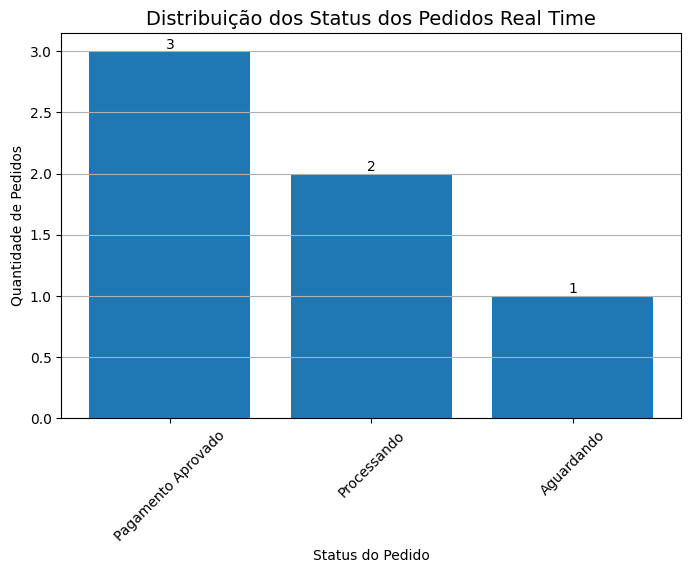

In [0]:
# ==================================================
# GRÁFICO - STATUS DOS PEDIDOS REAL TIME
# ==================================================


plt.figure(
    figsize=(8,5)
)


plt.bar(
    status_realtime["status_pedido"],
    status_realtime["quantidade"]
)


plt.title(
    "Distribuição dos Status dos Pedidos Real Time",
    fontsize=14
)


plt.xlabel(
    "Status do Pedido"
)


plt.ylabel(
    "Quantidade de Pedidos"
)


plt.xticks(
    rotation=45
)


# Exibe os valores acima das barras.

for i, valor in enumerate(
    status_realtime["quantidade"]
):
    
    plt.text(
        i,
        valor,
        str(valor),
        ha="center",
        va="bottom"
    )


plt.grid(
    axis="y"
)


plt.show()

# Métodos de Pagamento - Eventos Real Time

Nesta etapa será analisada a distribuição dos métodos de pagamento utilizados nos novos pedidos recebidos pela janela de processamento em tempo real.

O objetivo é comparar o comportamento atual dos pedidos com o padrão histórico identificado anteriormente.

In [0]:
# ==================================================
# MÉTODOS DE PAGAMENTO - REAL TIME
# ==================================================


# Conta a quantidade de pedidos
# por método de pagamento na janela atual.

pagamentos_realtime = (
    df_realtime
    ["metodo_pagamento"]
    .value_counts()
    .reset_index()
)



# Renomeia as colunas.

pagamentos_realtime.columns = [
    "metodo_pagamento",
    "quantidade"
]


# Exibe o resultado.

pagamentos_realtime

,metodo_pagamento,quantidade
0,boleto,3
1,pix,2
2,cartão débito,1


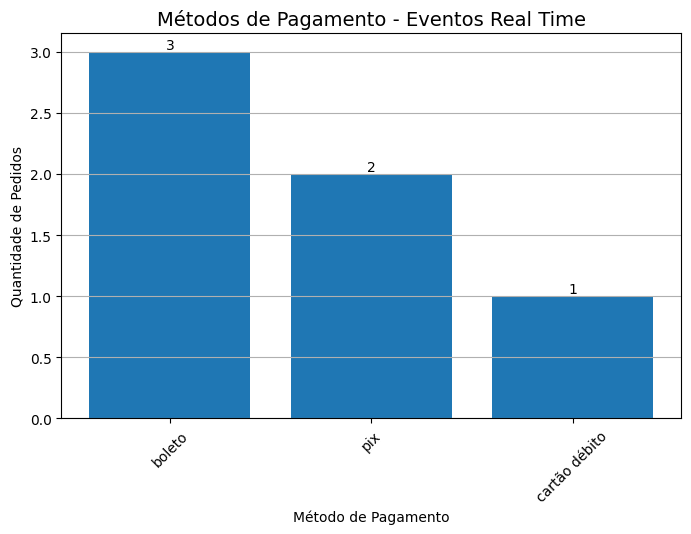

In [0]:
# ==================================================
# GRÁFICO - MÉTODOS DE PAGAMENTO REAL TIME
# ==================================================


plt.figure(
    figsize=(8,5)
)


plt.bar(
    pagamentos_realtime["metodo_pagamento"],
    pagamentos_realtime["quantidade"]
)


plt.title(
    "Métodos de Pagamento - Eventos Real Time",
    fontsize=14
)


plt.xlabel(
    "Método de Pagamento"
)


plt.ylabel(
    "Quantidade de Pedidos"
)


plt.xticks(
    rotation=45
)


# Exibe os valores acima das barras.

for i, valor in enumerate(
    pagamentos_realtime["quantidade"]
):

    plt.text(
        i,
        valor,
        str(valor),
        ha="center",
        va="bottom"
    )


plt.grid(
    axis="y"
)


plt.show()

# Comparação Histórico x Real Time

Nesta etapa será realizada a comparação entre os dados históricos e os eventos recebidos em tempo real.

O objetivo é demonstrar a diferença entre:

- dados acumulados para análise histórica;
- novos eventos chegando continuamente pelo fluxo de streaming.

In [0]:
# ==================================================
# COMPARAÇÃO HISTÓRICO X REAL TIME
# ==================================================


# Cria um resumo comparativo
# entre as duas fontes analisadas.

comparacao = pd.DataFrame(
    {
        "Indicador": [
            "Quantidade de registros",
            "Valor movimentado"
        ],
        
        "Histórico Batch": [
            len(df_historico),
            df_historico["valor_total"].sum()
        ],
        
        "Eventos Real Time": [
            len(df_realtime),
            df_realtime["valor_total"].sum()
        ]
    }
)



comparacao

,Indicador,Histórico Batch,Eventos Real Time
0,Quantidade de registros,90335.00,6.00
1,Valor movimentado,76067496.82,754.66


# Conclusão da Comparação Batch x Real Time

A análise demonstrou a diferença entre os dados históricos e os eventos recebidos em tempo real.

O histórico Batch concentra 90.335 pedidos acumulados, permitindo análises de comportamento e indicadores de negócio.

Já a camada Real Time representa uma janela específica de eventos recentes, contendo 6 novos pedidos e R$ 754,66 em movimentação.

A integração das duas visões permite acompanhar tanto o comportamento histórico do negócio quanto os eventos que estão ocorrendo no momento.

# Consolidação dos Dados Batch + Real Time

Nesta etapa será criada uma visão consolidada da tabela
`ecommerce_pedidos`.

Serão combinados:

- Histórico completo (`batch-data`);
- Novos eventos recebidos (`real-time-data`).

Após a união, será realizada uma validação de duplicidade utilizando a chave:

id_pedido


O objetivo é garantir uma tabela única e consistente para disponibilização analítica.

In [0]:
# ==================================================
# CONSOLIDAÇÃO HISTÓRICO + REAL TIME
# ==================================================


# Cria uma cópia do histórico para preservar
# o DataFrame original.

df_pedidos_consolidado = (
    df_historico
    .copy()
)



# Adiciona os novos eventos recebidos
# pela camada Real Time.

df_pedidos_consolidado = pd.concat(
    [
        df_pedidos_consolidado,
        df_realtime
    ],
    ignore_index=True
)



# Remove possíveis pedidos duplicados.
# A coluna id_pedido representa a chave
# única dos pedidos.

df_pedidos_consolidado = (
    df_pedidos_consolidado
    .drop_duplicates(
        subset="id_pedido",
        keep="last"
    )
)



print(
    "Consolidação realizada com sucesso!"
)


print(
    "Quantidade final de registros:"
)


print(
    len(df_pedidos_consolidado)
)

Consolidação realizada com sucesso!
Quantidade final de registros:
90341


# Validação da Tabela Consolidada

Nesta etapa será validada a integridade da tabela final após a união dos dados históricos e eventos em tempo real.

Serão analisados:

- quantidade total de registros;
- quantidade de pedidos únicos;
- possíveis duplicidades utilizando `id_pedido`.

In [0]:
# ==================================================
# VALIDAÇÃO DA TABELA CONSOLIDADA
# ==================================================


# Quantidade total de registros após consolidação.

total_consolidado = (
    len(df_pedidos_consolidado)
)



# Quantidade de pedidos únicos.

pedidos_unicos_consolidado = (
    df_pedidos_consolidado["id_pedido"]
    .nunique()
)



# Calcula possíveis duplicidades.

duplicidades_consolidado = (
    total_consolidado
    -
    pedidos_unicos_consolidado
)



print(
    "Total de registros:",
    total_consolidado
)


print(
    "Pedidos únicos:",
    pedidos_unicos_consolidado
)


print(
    "Duplicidades encontradas:",
    duplicidades_consolidado
)

Total de registros: 90341
Pedidos únicos: 90341
Duplicidades encontradas: 0


# Persistência dos Dados no SQL Server

Nesta etapa será realizada a disponibilização da tabela consolidada
`ecommerce_pedidos` no SQL Server Azure.

A tabela final contém:

- dados históricos provenientes do Batch;
- novos eventos recebidos da camada Real Time;
- registros validados sem duplicidade.

Tabela destino:

```sql
squad2.ecommerce_pedidos

In [0]:
# ==================================================
# RECARREGAMENTO DAS CONFIGURAÇÕES SQL
# ==================================================

# Biblioteca responsável por carregar
# variáveis do arquivo .env.

from dotenv import load_dotenv


# Biblioteca padrão para acessar
# variáveis de ambiente.

import os



# Carrega novamente o arquivo .env.

load_dotenv()



# Recupera as configurações do SQL Server.

SQL_HOST = os.getenv(
    "SQL_HOST"
)


SQL_DATABASE = os.getenv(
    "SQL_DATABASE"
)


SQL_USERNAME = os.getenv(
    "SQL_USERNAME"
)


SQL_PASSWORD = os.getenv(
    "SQL_PASSWORD"
)



print(
    "Configurações SQL recarregadas!"
)

Configurações SQL recarregadas!


In [0]:
# ==================================================
# RECRIAÇÃO DO DATAFRAME SPARK
# ==================================================


# Converte novamente o DataFrame Pandas consolidado
# para um DataFrame Spark.

df_spark_pedidos = (
    spark
    .createDataFrame(
        df_pedidos_consolidado
    )
)


# Valida a quantidade de registros.

print(
    "Quantidade de registros Spark:"
)


print(
    df_spark_pedidos.count()
)

Quantidade de registros Spark:
90341


In [0]:
# ==================================================
# INGESTÃO NO SQL SERVER
# TABELA: squad2.ecommerce_pedidos
# ==================================================


# Realiza a gravação do DataFrame Spark
# utilizando o conector SQL Server do Databricks.

df_spark_pedidos.write \
    .format("sqlserver") \
    .option(
        "host",
        SQL_HOST
    ) \
    .option(
        "port",
        "1433"
    ) \
    .option(
        "database",
        SQL_DATABASE
    ) \
    .option(
        "dbtable",
        "squad2.ecommerce_pedidos"
    ) \
    .option(
        "user",
        SQL_USERNAME
    ) \
    .option(
        "password",
        SQL_PASSWORD
    ) \
    .option(
        "encrypt",
        "true"
    ) \
    .mode(
        "overwrite"
    ) \
    .save()


print(
    "Tabela squad2.ecommerce_pedidos gravada com sucesso!"
)

Tabela squad2.ecommerce_pedidos gravada com sucesso!
